In [1]:
from curl_cffi import requests
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import talib as ta
import seaborn as sns
sns.set_theme(style="whitegrid")
import pickle
import duckdb as db

In [2]:
window = 20

In [3]:
with open('../../data/n200_5yr_v3.pickle', 'rb') as f:
    stock_data = pickle.load(f)

with open('../../data/nifty_data.pkl', 'rb') as f:
    index_data = pickle.load(f)

with open('../../data/nifty_regimes_m.pkl', 'rb') as f:
    regime = pickle.load(f)
    
n200 = pd.read_csv("../../data/ind_nifty500list.csv")

In [4]:
index_data = index_data.reset_index().rename(columns={'index': 'Date', 'Close': 'Index_Close'})[['Date', 'Index_Close']]

In [5]:
index_data["Date"] = index_data['Date'].dt.tz_localize(None)
index_data["index_ret_1d"]= index_data['Index_Close'].pct_change(1)
index_data["index_ret_5d"]= index_data['Index_Close'].pct_change(5)
index_data["index_ret_20d"]= index_data['Index_Close'].pct_change(20)
index_data["index_vol"] = index_data["index_ret_1d"].rolling(window).std()
index_data["index_vol_5d"] = index_data["index_ret_1d"].rolling(5).std()
index_data["index_vol_20d"] = index_data["index_ret_1d"].rolling(20).std()
index_data=index_data.set_index("Date")
full_idx = pd.date_range(index_data.index.min(), index_data.index.max(), freq="D")
index_data = index_data.reindex(full_idx)
index_data=index_data.bfill().ffill()
index_data=index_data.reset_index()
index_data=index_data.rename(columns={'index': 'Date'})

In [6]:
stock_data = stock_data.replace(0, np.nan)

In [7]:
# stock_data["Volume"] = stock_data.groupby('Symbol', group_keys=False)["Volume"].apply(lambda group: group.interpolate())
stock_data["Volume"] = stock_data.groupby('Symbol')["Volume"].transform(lambda x: x.interpolate())
stock_data["stock_ret_1d"] = stock_data.groupby('Symbol')['Close'].transform(lambda x: x.pct_change(1))
stock_data["vol_norm"] = stock_data.groupby('Symbol')["Volume"].transform(lambda x: x / x.rolling(window).mean())
stock_data["obv"] = stock_data.groupby('Symbol').apply(lambda g: ta.OBV(g["Close"], g["Volume"]), include_groups=False).reset_index(level=0, drop=True)
stock_data["rsi"] = stock_data.groupby('Symbol').apply(lambda g: ta.RSI(g["Close"], timeperiod=14), include_groups=False).reset_index(level=0, drop=True)
stock_data["adx"] = stock_data.groupby('Symbol').apply(lambda g: ta.ADX(g["High"], g["Low"], g["Close"], timeperiod=14), include_groups=False).reset_index(level=0, drop=True)
stock_data["atr"] = stock_data.groupby('Symbol').apply(lambda g: ta.ATR(g["High"], g["Low"], g["Close"], timeperiod=14), include_groups=False).reset_index(level=0, drop=True)


In [8]:
merged = pd.merge(stock_data, index_data, on='Date', how='left')

In [9]:
merged

,Date,Open,High,Low,Close,Volume,Symbol,stock_ret_1d,vol_norm,obv,rsi,adx,atr,Index_Close,index_ret_1d,index_ret_5d,index_ret_20d,index_vol,index_vol_5d,index_vol_20d
0,2015-09-16,977.616089,989.007507,951.472412,957.844666,46055.0,ABB,NaN,NaN,46055.0,NaN,NaN,NaN,7899.149902,0.008947,0.010302,-0.070158,0.018447,0.007370,0.018447
1,2015-09-18,977.616089,987.392639,957.757324,978.969055,129547.0,ABB,0.022054,NaN,175602.0,NaN,NaN,NaN,7981.899902,0.010476,0.024884,-0.046681,0.018509,0.007260,0.018509
2,2015-09-21,973.295166,991.539001,964.566040,966.486450,34553.0,ABB,-0.012751,NaN,141049.0,NaN,NaN,NaN,7977.100098,-0.000601,0.024110,-0.038898,0.018448,0.007391,0.018448
3,2015-09-22,979.361938,979.361938,960.201599,962.602051,13607.0,ABB,-0.004019,NaN,127442.0,NaN,NaN,NaN,7812.000000,-0.020697,-0.007653,0.000384,0.013498,0.012627,0.013498
4,2015-09-23,960.201355,964.478638,944.838135,959.677612,15296.0,ABB,-0.003038,NaN,112146.0,NaN,NaN,NaN,7845.950195,0.004346,0.002152,-0.004410,0.013370,0.012611,0.013370
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430042,2025-09-09,1010.000000,1038.699951,1009.200012,1035.599976,1228793.0,ZYDUSLIFE,0.025702,0.974756,682849209.0,67.138822,23.612821,21.367447,24868.599609,0.003853,0.011758,0.020740,0.005733,0.002244,0.005733
430043,2025-09-10,1040.550049,1049.849976,1033.000000,1039.599976,1086228.0,ZYDUSLIFE,0.003863,0.855775,683935437.0,68.108620,25.613065,21.044771,24973.099609,0.004202,0.010441,0.015784,0.005469,0.001818,0.005469
430044,2025-09-11,1039.599976,1048.000000,1030.300049,1043.599976,537049.0,ZYDUSLIFE,0.003848,0.447328,684472486.0,69.090974,27.235275,20.805855,25005.500000,0.001297,0.010964,0.021158,0.005352,0.001738,0.005352
430045,2025-09-12,1048.300049,1054.599976,1042.000000,1044.750000,559927.0,ZYDUSLIFE,0.001102,0.469458,685032413.0,69.382978,28.941201,20.219721,25114.000000,0.004339,0.015076,0.020092,0.005313,0.001562,0.005313


In [10]:
# with open("../../data/index_stocked_merged.pkl", 'wb') as f:
#     pickle.dump(merged, f)

# with open("../../data/index_stocked_merged.pkl", 'rb') as f:
#     merged = pickle.load(f)

In [11]:
regime=regime.reset_index().rename(columns={"index": "Date"})

In [12]:
merged.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Symbol',
       'stock_ret_1d', 'vol_norm', 'obv', 'rsi', 'adx', 'atr', 'Index_Close',
       'index_ret_1d', 'index_ret_5d', 'index_ret_20d', 'index_vol',
       'index_vol_5d', 'index_vol_20d'],
      dtype='object')

In [13]:
merged

,Date,Open,High,Low,Close,Volume,Symbol,stock_ret_1d,vol_norm,obv,rsi,adx,atr,Index_Close,index_ret_1d,index_ret_5d,index_ret_20d,index_vol,index_vol_5d,index_vol_20d
0,2015-09-16,977.616089,989.007507,951.472412,957.844666,46055.0,ABB,NaN,NaN,46055.0,NaN,NaN,NaN,7899.149902,0.008947,0.010302,-0.070158,0.018447,0.007370,0.018447
1,2015-09-18,977.616089,987.392639,957.757324,978.969055,129547.0,ABB,0.022054,NaN,175602.0,NaN,NaN,NaN,7981.899902,0.010476,0.024884,-0.046681,0.018509,0.007260,0.018509
2,2015-09-21,973.295166,991.539001,964.566040,966.486450,34553.0,ABB,-0.012751,NaN,141049.0,NaN,NaN,NaN,7977.100098,-0.000601,0.024110,-0.038898,0.018448,0.007391,0.018448
3,2015-09-22,979.361938,979.361938,960.201599,962.602051,13607.0,ABB,-0.004019,NaN,127442.0,NaN,NaN,NaN,7812.000000,-0.020697,-0.007653,0.000384,0.013498,0.012627,0.013498
4,2015-09-23,960.201355,964.478638,944.838135,959.677612,15296.0,ABB,-0.003038,NaN,112146.0,NaN,NaN,NaN,7845.950195,0.004346,0.002152,-0.004410,0.013370,0.012611,0.013370
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430042,2025-09-09,1010.000000,1038.699951,1009.200012,1035.599976,1228793.0,ZYDUSLIFE,0.025702,0.974756,682849209.0,67.138822,23.612821,21.367447,24868.599609,0.003853,0.011758,0.020740,0.005733,0.002244,0.005733
430043,2025-09-10,1040.550049,1049.849976,1033.000000,1039.599976,1086228.0,ZYDUSLIFE,0.003863,0.855775,683935437.0,68.108620,25.613065,21.044771,24973.099609,0.004202,0.010441,0.015784,0.005469,0.001818,0.005469
430044,2025-09-11,1039.599976,1048.000000,1030.300049,1043.599976,537049.0,ZYDUSLIFE,0.003848,0.447328,684472486.0,69.090974,27.235275,20.805855,25005.500000,0.001297,0.010964,0.021158,0.005352,0.001738,0.005352
430045,2025-09-12,1048.300049,1054.599976,1042.000000,1044.750000,559927.0,ZYDUSLIFE,0.001102,0.469458,685032413.0,69.382978,28.941201,20.219721,25114.000000,0.004339,0.015076,0.020092,0.005313,0.001562,0.005313


In [14]:
?ta.WILLR

Signature: ta.WILLR(high, low, close, timeperiod=-2147483648)
Docstring:
WILLR(high, low, close[, timeperiod=?])

Williams' %R (Momentum Indicators)

Inputs:
    prices: ['high', 'low', 'close']
Parameters:
    timeperiod: 14
Outputs:
    real
Type:      function

In [15]:
def add_indicators(df: pd.DataFrame, window:int=20) -> pd.DataFrame:
    """
    Add stock-only indicators + stock-index relationship features
    for a stacked dataframe of multiple stocks.
    
    Required columns:
    ['Symbol','Date','Open','High','Low','Close','Volume','Index_Close']
    """

    df = df.copy()

    grouped = df.groupby("Symbol", group_keys=False)

    # ------------------------------
    # 1. Trend / Moving Averages
    # ------------------------------
    df["EMA_9"]   = grouped["Close"].transform(lambda x: ta.EMA(x, 9))
    df["EMA_30"]  = grouped["Close"].transform(lambda x: ta.EMA(x, 30))
    df["EMA_100"] = grouped["Close"].transform(lambda x: ta.EMA(x, 100))

    # Price ratios
    # df["ema_9_ratio"]   = df["Close"] / df["EMA_9"]
    # df["ema_30_ratio"]  = df["Close"] / df["EMA_30"]
    # df["ema_100_ratio"] = df["Close"] / df["EMA_100"]

    # ------------------------------
    # 2. Directional Indicators
    # ------------------------------
    df["plus_di"]  = grouped.apply(lambda g: ta.PLUS_DI(g["High"], g["Low"], g["Close"], timeperiod=14), include_groups=False)
    df["minus_di"] = grouped.apply(lambda g: ta.MINUS_DI(g["High"], g["Low"], g["Close"], timeperiod=14), include_groups=False)
    # df["adx"]      = grouped.apply(lambda g: ta.ADX(g["High"], g["Low"], g["Close"], timeperiod=14), include_groups=False)


    # ------------------------------
    # 3. Oscillators / Momentum
    # ------------------------------
    # df["rsi"] = grouped["Close"].transform(lambda x: ta.RSI(x, 14))
    for n in [5, 10, 20]:
        df[f"rsi_{n}_chg"] = grouped["rsi"].transform(lambda x: x.pct_change(n))
        df[f"adx_{n}_chg"] = grouped["adx"].transform(lambda x: x.pct_change(n))
        df[f"roc_{n}"] = grouped["Close"].transform(lambda x: ta.ROC(x, n))
        df[f"atr_{n}_chg"] = grouped["atr"].transform(lambda x: x.pct_change(n))
        df[f"vol_chg_{n}d"] = df.groupby('Symbol')["Volume"].transform(lambda x: x.pct_change(n))
        df[f"volatility_{n}d"] = grouped["stock_ret_1d"].transform(lambda x: x.rolling(n).std())
        df[f"{n}_days_high"] = grouped["High"].transform(lambda x: x.rolling(n).max()) / df["Close"]

    df["william"] = grouped.apply(lambda g: ta.WILLR(g["High"], g["Low"], g["Close"], timeperiod=140), include_groups=False)


    

    # ------------------------------
    # 4. ATR-based Volatility
    # ------------------------------
    # for n in [5, 10, 20]:
    #     df[f"atr_{n}"] = grouped.apply(lambda g: ta.ATR(g["High"], g["Low"], g["Close"], timeperiod=n), include_groups=False)
    #     df[f"atr_{n}"] = df[f"atr_{n}"] / df["Close"]
    
    # ------------------------------
    # 5. Returns & Rolling Volatility
    # ------------------------------
    # df["stock_ret_1d"]  = grouped["Close"].transform(lambda x: x.pct_change(1))

    # for n in [5, 14, 30]:
    #     df[f"stock_ret_{n}d"] = grouped["Close"].transform(lambda x: x.pct_change(n))

    # for n in [5, 10, 20]:

    # ------------------------------
    # 6. Rolling Highs normalized
    # ------------------------------
    # for n in [5, 14, 30]:
        # df[f"{n}_days_high"] = grouped["High"].transform(lambda x: x.rolling(n).max()) / df["Close"]

    # ------------------------------
    # 7. MACD (normalized by Close)
    # ------------------------------
    # def macd_apply(x):
    #     macd, macd_signal, macd_hist = ta.MACD(x, fastperiod=12, slowperiod=26, signalperiod=9)
    #     return pd.DataFrame({"macd": macd, "macd_signal": macd_signal, "macd_hist": macd_hist}, index=x.index)

    # macd_df = grouped["Close"].apply(macd_apply)
    # macd_df["macd"]        = macd_df["macd"] / df["Close"]
    # macd_df["macd_signal"] = macd_df["macd_signal"] / df["Close"]
    # macd_df["macd_hist"]   = macd_df["macd_hist"] / df["Close"]
    # df = df.join(macd_df)


    # ------------------------------
    # 8. Stock vs Index Features
    # ------------------------------

    # relative return
    # df["rel_ret"] = df["stock_ret_1d"] - df["index_ret_1d"]

    # rolling beta
    def rolling_beta(stock_ret, index_ret, win=20):
        cov = stock_ret.rolling(win).cov(index_ret)
        var = index_ret.rolling(win).var()
        return cov / var
    

    df["beta"] = grouped.apply(lambda g: rolling_beta(g["stock_ret_1d"], g["index_ret_1d"], window), include_groups=False)

    # rolling correlation
    df["corr"] = grouped.apply(lambda g: g["stock_ret_1d"].rolling(window).corr(g["index_ret_1d"]), include_groups=False)

    # excess volatility
    df["stock_vol"] = grouped["stock_ret_1d"].transform(lambda x: x.rolling(window).std())
    df["excess_vol"] = df["stock_vol"] - df["index_vol"]

    # ------------------------------
    # 9. Range-Based Volatility
    # ------------------------------
    # df["parkinson_vol"] = grouped.apply(lambda g: np.sqrt(1/(4*np.log(2)) * (np.log(g["High"]/g["Low"]))**2), include_groups=False)

    # df["gk_vol"] = grouped.apply(
    #     lambda g: np.sqrt(
    #         0.5*(np.log(g["High"]/g["Low"]))**2 -
    #         (2*np.log(2)-1)*(np.log(g["Close"]/g["Open"]))**2
    #     ),
    #     include_groups=False
    # )
    df["volatility_of_volatility"] = grouped["stock_ret_1d"].transform(lambda x: x.rolling(window).std().rolling(window).std())

    # ------------------------------
    # 10. Distribution Shape
    # ------------------------------
    # df["skew"] = grouped["stock_ret_1d"].transform(lambda x: x.rolling(window).skew())
    # df["kurt"] = grouped["stock_ret_1d"].transform(lambda x: x.rolling(window).kurt())

    def downside_semivariance(x):
        neg = x[x < 0]
        return (neg**2).mean()

    df["dsv"] = grouped["stock_ret_1d"].transform(lambda x: x.rolling(window).apply(downside_semivariance, raw=False))

    # ------------------------------
    # 11. Volume Features
    # ------------------------------
    # df["vol_norm"] = grouped["Volume"].transform(lambda x: x / x.rolling(window).mean()) # drop it later
    df["vol_z"] = grouped["vol_norm"].transform(lambda x: (x - x.rolling(window).mean()) / x.rolling(window).std())

    df["vol_vol_ratio"] = grouped.apply(
        lambda g: (g["Volume"] / g["Volume"].rolling(window).mean()) / g["stock_ret_1d"].rolling(window).std(),
        include_groups=False
    )

    # df["obv"] = grouped.apply(lambda g: ta.OBV(g["Close"], g["Volume"]), include_groups=False) # drop it later
    df["obv_z"] = grouped["obv"].transform(lambda x: (x - x.rolling(window).mean()) / x.rolling(window).std())


    df["vwap_dev"] = grouped.apply(
        lambda g: (g["Close"] - (g["High"]+g["Low"]+g["Close"])/3) / ta.ATR(g["High"], g["Low"], g["Close"], timeperiod=14),
        include_groups=False
    )

    return df

In [16]:
modified = add_indicators(merged, window=window)

In [17]:
modified.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Symbol',
       'stock_ret_1d', 'vol_norm', 'obv', 'rsi', 'adx', 'atr', 'Index_Close',
       'index_ret_1d', 'index_ret_5d', 'index_ret_20d', 'index_vol',
       'index_vol_5d', 'index_vol_20d', 'EMA_9', 'EMA_30', 'EMA_100',
       'plus_di', 'minus_di', 'rsi_5_chg', 'adx_5_chg', 'roc_5', 'atr_5_chg',
       'vol_chg_5d', 'volatility_5d', '5_days_high', 'rsi_10_chg',
       'adx_10_chg', 'roc_10', 'atr_10_chg', 'vol_chg_10d', 'volatility_10d',
       '10_days_high', 'rsi_20_chg', 'adx_20_chg', 'roc_20', 'atr_20_chg',
       'vol_chg_20d', 'volatility_20d', '20_days_high', 'william', 'beta',
       'corr', 'stock_vol', 'excess_vol', 'volatility_of_volatility', 'dsv',
       'vol_z', 'vol_vol_ratio', 'obv_z', 'vwap_dev'],
      dtype='object')

In [18]:
df = modified.dropna().copy()

In [19]:
def check_if_uptrend(row):
    william_check = 0
    adx_check = 0
    if row['william'] < -25: 
        william_check = 1
    if row['adx'] > 40:
        adx_check = 1
    if william_check and adx_check:
        return 1
    else:
        return 0
    
def exit_signal(row):
    if row['william'] > -25:
        return 1
    else:
        return 0

In [20]:
# df["is_uptrend"] = df.apply(check_if_uptrend, axis=1)
# df["signal"] = df["is_uptrend"].where(df["is_uptrend"] != df["is_uptrend"].shift(), 0)

df['buy_signal'] = df.apply(check_if_uptrend, axis=1)
df['exit_signal'] = df.apply(exit_signal, axis=1)

In [21]:
df

,Date,Open,High,Low,Close,Volume,Symbol,stock_ret_1d,vol_norm,obv,...,stock_vol,excess_vol,volatility_of_volatility,dsv,vol_z,vol_vol_ratio,obv_z,vwap_dev,buy_signal,exit_signal
139,2016-04-18,1193.608643,1201.619873,1164.453613,1175.747925,46131.0,ABB,-0.006657,0.555973,2437410.0,...,0.017984,0.008043,0.002334,0.000252,-0.727571,30.914747,1.016070,-0.116475,0,1
140,2016-04-20,1177.586548,1197.723755,1153.334351,1158.981567,65491.0,ABB,-0.014260,0.773068,2371919.0,...,0.018078,0.008128,0.002376,0.000259,-0.430574,42.763225,0.764822,-0.263229,0,1
141,2016-04-21,1164.453491,1172.858521,1160.426025,1164.803711,34882.0,ABB,0.005023,0.414804,2406801.0,...,0.017891,0.007919,0.002389,0.000259,-0.963997,23.185171,0.787978,-0.030714,0,1
142,2016-04-22,1164.453735,1183.715332,1155.698486,1170.888916,76485.0,ABB,0.005224,0.891501,2483286.0,...,0.017898,0.008148,0.002380,0.000259,-0.252193,49.809358,0.946833,0.020175,0,1
143,2016-04-25,1181.439087,1207.354614,1161.039062,1178.111938,318260.0,ABB,0.006169,3.234139,2801546.0,...,0.017710,0.008194,0.002338,0.000259,2.580756,182.615720,1.813575,-0.102500,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430042,2025-09-09,1010.000000,1038.699951,1009.200012,1035.599976,1228793.0,ZYDUSLIFE,0.025702,0.974756,682849209.0,...,0.015180,0.009448,0.001255,0.000268,-0.374341,64.211158,2.005701,0.363478,0,1
430043,2025-09-10,1040.550049,1049.849976,1033.000000,1039.599976,1086228.0,ZYDUSLIFE,0.003863,0.855775,683935437.0,...,0.015151,0.009682,0.001192,0.000268,-0.521719,56.482552,2.041383,-0.057819,0,1
430044,2025-09-11,1039.599976,1048.000000,1030.300049,1043.599976,537049.0,ZYDUSLIFE,0.003848,0.447328,684472486.0,...,0.013388,0.008036,0.001351,0.000268,-0.994185,33.411427,1.887603,0.142588,0,1
430045,2025-09-12,1048.300049,1054.599976,1042.000000,1044.750000,559927.0,ZYDUSLIFE,0.001102,0.469458,685032413.0,...,0.013381,0.008068,0.001481,0.000268,-0.921267,35.084434,1.767547,-0.117049,0,1


In [22]:
def build_trades_df_for_symbol(df: pd.DataFrame, symbol: str = "INFY") -> pd.DataFrame:
    trades_arr = []
    trade_entered = False
    for row in df.iterrows():
        row = row[1]
        if row["buy_signal"] == 1 and not trade_entered:
            entry_price = row["Close"]
            entry_date = row["Date"]
            trade_entered = True
        if trade_entered and row["exit_signal"] == 1:
            exit_price = row["Close"]
            exit_date = row["Date"]
            trades_arr.append([entry_date, entry_price, exit_date, exit_price])
            trade_entered = False
        # exit if no exit till end of data
        if trade_entered and row.name == df.index[-1]:
            exit_price = row["Close"]
            exit_date = row["Date"]
            trades_arr.append([entry_date, entry_price, exit_date, exit_price])
            trade_entered = False
    return pd.DataFrame(trades_arr, columns=["entry_date", "entry_price", "exit_date", "exit_price"])

trades_df = pd.DataFrame()
for symbol in df["Symbol"].unique():
    _ = build_trades_df_for_symbol(df[df["Symbol"]==symbol], symbol=symbol)
    if _.empty:
        continue
    _["Symbol"] = symbol
    trades_df = pd.concat([trades_df, _], axis=0)

In [23]:
trades_df

,entry_date,entry_price,exit_date,exit_price,Symbol
0,2016-04-26,1128.557007,2017-02-10,1101.415527,ABB
1,2018-02-05,1429.653564,2018-09-12,1290.105103,ABB
2,2018-09-19,1268.598267,2018-09-25,1259.607544,ABB
3,2019-05-09,1225.911133,2019-05-20,1271.200562,ABB
4,2020-03-19,872.907959,2020-11-09,929.864868,ABB
...,...,...,...,...,...
0,2017-12-14,380.795654,2018-09-03,380.371155,ZYDUSLIFE
1,2019-05-14,244.527649,2019-12-06,243.216965,ZYDUSLIFE
2,2021-05-18,582.933228,2021-05-19,593.108582,ZYDUSLIFE
3,2021-08-20,518.886597,2022-08-16,389.424805,ZYDUSLIFE


In [24]:
to_drop = [ 'Open', 'High', 'Low', 'Volume', 'EMA_9', 'EMA_30', 'EMA_100', 'is_uptrend', 'signal','obv','vol_norm', 'atr']

In [25]:
trades_df["return"] = (trades_df["exit_price"] - trades_df["entry_price"])*100/trades_df["entry_price"]

In [24]:
enhanced_trades_df = trades_df.merge(df, left_on=["Symbol", "entry_date"], right_on=["Symbol", "Date"], how="left").drop(columns=["Date", *to_drop]).reset_index(drop=True)

In [25]:
enhanced_trades_df["result"] = np.where(enhanced_trades_df["return"] > 0, 1, 0)

In [26]:
enhanced_trades_df=enhanced_trades_df.merge(n200[["Symbol", "Industry"]], on="Symbol")

In [26]:
trades_df

,entry_date,entry_price,exit_date,exit_price,Symbol,return
0,2016-04-26,1128.557007,2017-02-10,1101.415527,ABB,-2.404972
1,2018-02-05,1429.653564,2018-09-12,1290.105103,ABB,-9.760998
2,2018-09-19,1268.598267,2018-09-25,1259.607544,ABB,-0.708713
3,2019-05-09,1225.911133,2019-05-20,1271.200562,ABB,3.694348
4,2020-03-19,872.907959,2020-11-09,929.864868,ABB,6.524962
...,...,...,...,...,...,...
0,2017-12-14,380.795654,2018-09-03,380.371155,ZYDUSLIFE,-0.111477
1,2019-05-14,244.527649,2019-12-06,243.216965,ZYDUSLIFE,-0.536007
2,2021-05-18,582.933228,2021-05-19,593.108582,ZYDUSLIFE,1.745544
3,2021-08-20,518.886597,2022-08-16,389.424805,ZYDUSLIFE,-24.949920


<Axes: xlabel='exit_date'>

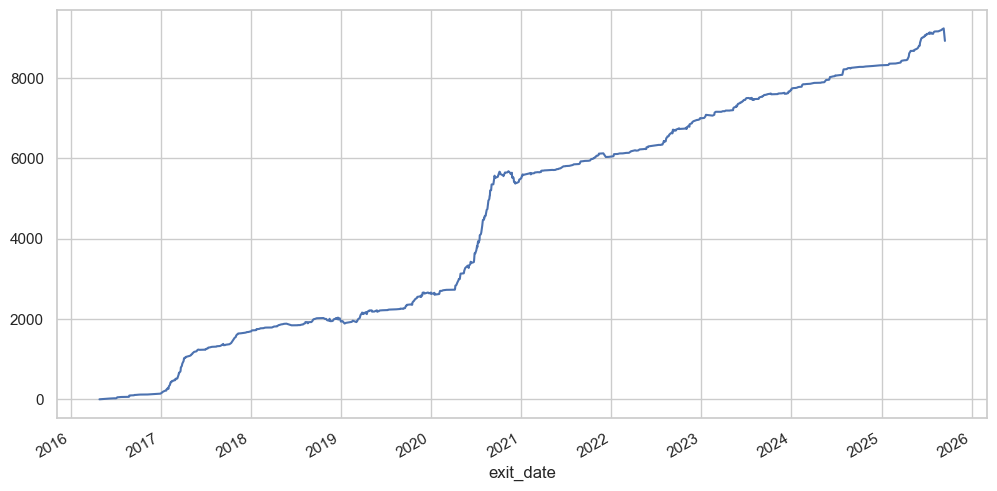

In [45]:
grouped = trades_df.groupby("exit_date").agg({"return": "sum"}).sort_values("exit_date")
grouped["cum_return"] = grouped["return"].cumsum()
grouped["cum_return"].plot(figsize=(12,6))

<Axes: ylabel='entry_month'>

<Figure size 1500x600 with 0 Axes>

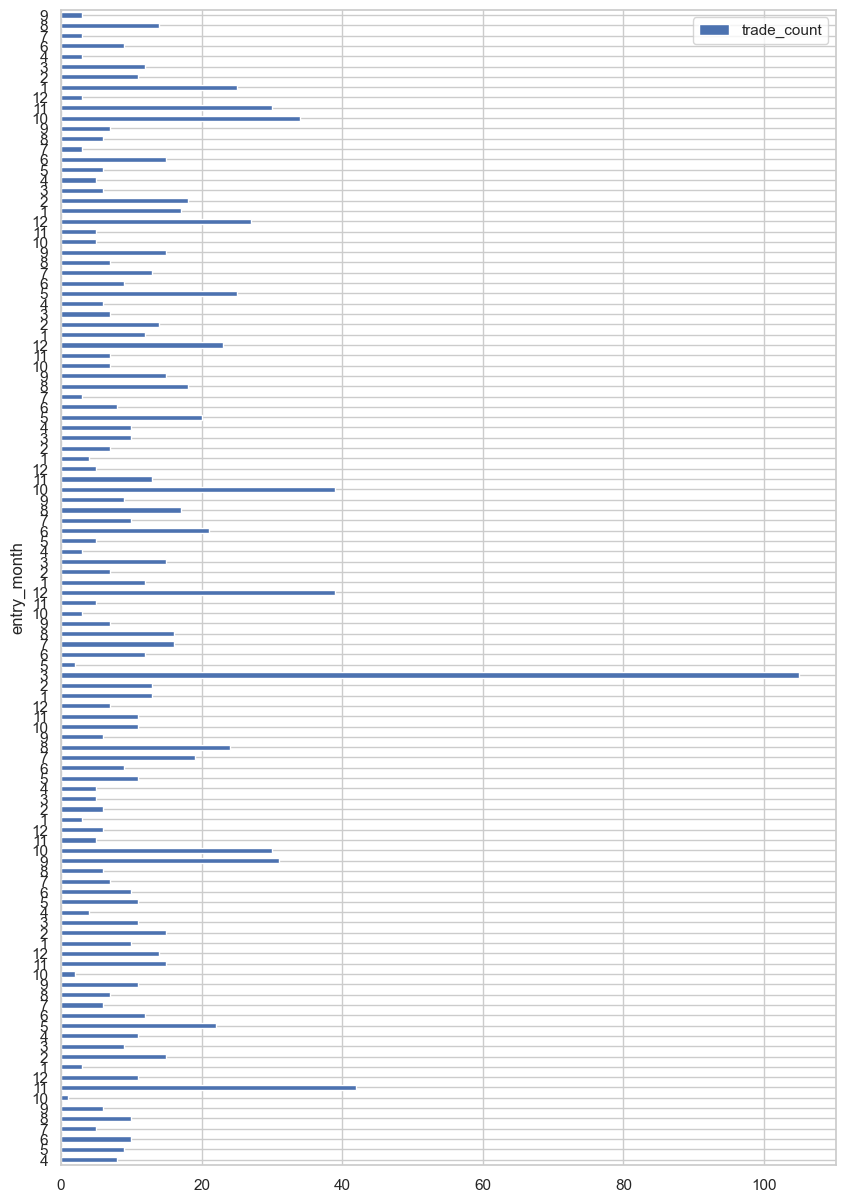

In [ ]:
plt.figure(figsize=(15,6))
db.sql("""
select month(entry_date) entry_month, year(entry_date) entry_year, count(*) trade_count from trades_df group by entry_year, entry_month order by entry_year, entry_month;
""").to_df().plot(x='entry_month', y='trade_count', kind='barh', figsize=(10,15));

In [31]:
grouped = enhanced_trades_df.groupby("Industry")["result"].agg(["sum", "count"])
grouped.rename(columns={"sum": "success_count", "count": "total"}, inplace=True)
grouped["fail_count"] = grouped["total"] - grouped["success_count"]

# Step 2: Proportions
total_success = grouped["success_count"].sum()
total_fail = grouped["fail_count"].sum()

grouped["dist_success"] = grouped["success_count"] / total_success
grouped["dist_fail"] = grouped["fail_count"] / total_fail

# Step 3: WoE = log(success_dist / fail_dist)
# add smoothing to avoid divide-by-zero
eps = 1e-6
grouped["WoE"] = np.log((grouped["dist_success"] + eps) / (grouped["dist_fail"] + eps))

# Step 4: Map back to dataframe
enhanced_trades_df["Industry_woe"] = enhanced_trades_df["Industry"].map(grouped["WoE"])

In [32]:
enhanced_trades_df = enhanced_trades_df.sort_values(by="entry_date")

In [36]:
enhanced_trades_df["cluster_win_loss_ratio"] = enhanced_trades_df.groupby("hmm_cluster")["result"].transform(lambda x: (x==1).sum() / (x==0).sum())

In [38]:
with open('../../data/enhanced_trades_df_v2.pkl', 'wb') as f:
    pickle.dump(enhanced_trades_df, f)

# with open('../../data/enhanced_trades_df_v2.pkl', 'rb') as f:
#     enhanced_trades_df = pickle.load(f)

In [37]:
enhanced_trades_df

,Symbol,entry_date,entry_price,exit_date,exit_price,return,Close,stock_ret_1d,rsi,adx,...,dsv,vol_z,vol_vol_ratio,obv_z,vwap_dev,result,Industry,hmm_cluster,Industry_woe,cluster_win_loss_ratio
2396,NMDC,2016-03-09,13.149165,2016-04-28,13.738341,4.480711,13.149165,-0.015344,75.574806,33.866604,...,0.000438,-0.943376,13.231202,1.863594,0.137517,1,Metals & Mining,0.0,0.171921,0.815166
1419,HINDALCO,2016-03-21,80.699150,2016-03-30,82.575851,2.325553,80.699150,0.009390,66.985118,30.847063,...,0.000358,-0.152065,33.855358,0.968967,0.063425,1,Metals & Mining,3.0,0.171921,0.512195
3240,TATASTEEL,2016-03-21,22.325666,2016-05-05,24.403414,9.306541,22.325666,0.004467,73.931740,30.156950,...,0.000155,-0.579234,35.126138,1.071643,0.016532,1,Metals & Mining,3.0,0.171921,0.512195
598,BHARTIARTL,2016-03-22,299.554504,2016-04-01,286.365204,-4.402972,299.554504,-0.007776,68.502922,30.521119,...,0.000175,0.457509,83.115273,1.333358,0.015242,0,Telecommunication,3.0,-0.170878,0.512195
2815,RELIANCE,2016-03-22,229.608643,2016-03-28,223.593719,-2.619641,229.608643,0.010171,67.560319,30.172319,...,0.000280,0.116702,80.890779,1.781608,0.113989,0,Oil Gas & Consumable Fuels,3.0,0.041870,0.512195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1692,INDIGO,2025-08-27,6050.000000,2025-08-28,5727.000000,-5.338843,6050.000000,0.000000,57.705115,30.314948,...,0.000106,3.992301,603.398978,0.451727,0.000000,0,Services,1.0,-0.240706,0.744048
3580,VMM,2025-08-27,153.139999,2025-09-02,146.330002,-4.446910,153.139999,0.000000,68.060884,31.580026,...,0.000392,1.153450,218.252956,2.544196,0.000000,0,Consumer Services,1.0,0.189966,0.744048
3360,TITAN,2025-08-29,3628.800049,2025-09-15,3534.100098,-2.609677,3628.800049,-0.002447,64.093506,31.060234,...,0.000062,-0.379968,97.851273,1.078735,0.072640,0,Consumer Durables,1.0,0.183092,0.744048
2209,MFSL,2025-08-29,1602.199951,2025-09-04,1566.000000,-2.259390,1602.199951,-0.004041,53.859737,30.395963,...,0.000116,-0.450856,49.298656,0.452576,-0.124731,0,Financial Services,1.0,-0.029508,0.744048
